In [88]:
# Step 1: Import, loading, ydata, EDA 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from ydata_profiling import ProfileReport

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, RobustScaler, LabelEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from lazypredict.Supervised import LazyRegressor


# Load the dataset
data = pd.read_csv("C:\\Users\\Dell\\Desktop\\AAA 2024\\2024 Python Data Science\\Machine Learning\\BostonHousing.csv")

# ydata-profilling
# profile = ProfileReport(data, title = "BostonHousing_Report", explorative=True)
# profile.to_file("report_BostonHousing.html")
# print(os.path.abspath("report_BostonHousing.html"))

# Basic Information about the Dataset
# print(f"First 5 rows of the dataset:\n{data.head()}\n")
# print(f"Summary of the dataset (info):\n{data.info()}\n")
# print(f"Shape of the dataset (rows, columns): {data.shape}\n")
# print(f"Descriptive statistics for numerical columns:\n{data.describe()}\n")
# print(f"Missing values in each column:\n{data.isnull().sum()}\n")
# print(f"Number of unique values in each column:\n{data.nunique()}\n")
# print(f"List of columns in the dataset:\n{data.columns}\n")

In [89]:
# Step 2: Train Test Split 
X = data.drop(columns='medv')  
y = data['medv']
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# Print the shape of the resulting datasets
print(f"Training set (X): {x_train.shape}, Training set (y): {y_train.shape}")
print(f"Test set (X): {x_test.shape}, Test set (y): {y_test.shape}")

Training set (X): (404, 13), Training set (y): (404,)
Test set (X): (102, 13), Test set (y): (102,)


In [90]:
# Step 3: Preprocessing

# 3.1 Handle missing values using SimpleImputer
imputer = SimpleImputer(strategy='median')
x_train['rm'] = imputer.fit_transform(x_train[['rm']])  
x_test['rm'] = imputer.transform(x_test[['rm']])  

# 3.2 Handle outliers by capping values using IQR
def cap_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df[column] = df[column].clip(lower=lower_bound, upper=upper_bound)

# Apply outlier capping to columns in x_train and x_test
columns_with_outliers = ['crim', 'tax', 'rm']
for col in columns_with_outliers:
    cap_outliers(x_train, col)
    cap_outliers(x_test, col)

# 3.3 Apply RobustScaler for skewed features
scaler_robust = RobustScaler()
columns_to_check = ['zn', 'nox', 'dis', 'tax', 'lstat']
x_train[columns_to_check] = scaler_robust.fit_transform(x_train[columns_to_check])
x_test[columns_to_check] = scaler_robust.transform(x_test[columns_to_check])

# 3.4 Apply StandardScaler to numerical features
numerical_columns = ['crim', 'zn', 'indus', 'nox', 'rm', 'age', 'dis', 'rad', 'tax', 'ptratio', 'b', 'lstat']
scaler = StandardScaler()
x_train[numerical_columns] = scaler.fit_transform(x_train[numerical_columns])
x_test[numerical_columns] = scaler.transform(x_test[numerical_columns])

# 3.5 Encode categorical columns using LabelEncoder 
encoder = LabelEncoder()
x_train['chas'] = encoder.fit_transform(x_train['chas'])  
x_test['chas'] = encoder.transform(x_test['chas'])  

In [91]:
# # Step 4,5,6: Model Fitting, Test, Evaluation base on Different Models
# # Step 4,5,6: Model Fitting, Test, Evaluation (Linear Regression)
# model = LinearRegression()
# model.fit(x_train, y_train)
# y_predict = model.predict(x_test)

# # for i, j in zip(y_test, y_predict):
# #     print("Actual: {}. Predict: {}".format(i, j))

# print("MSE: {}".format(mean_squared_error(y_test, y_predict)))
# print("MAE: {}".format(mean_absolute_error(y_test, y_predict)))
# print("R2: {}".format(r2_score(y_test, y_predict)))

# # Out 
# # MSE: 24.694922203640793
# # MAE: 3.2736193663527358
# # R2: 0.663253126466249


In [92]:
# Step 7: Model Coefficients and Intercept
# Print the coefficients (weights for each feature)
# print(f"Coefficients: {model.coef_}\nIntercept: {model.intercept_}\n")

# Out 
# Coefficients: [-1.17292794  0.58670347  0.36981748  2.94201537 -1.73587807  3.17697485
#  -0.18726719 -2.91390027  2.54815371 -1.72077986 -2.06270035  1.17158645
#  -3.59137678]
# Intercept: 22.585350382020682

In [93]:
# # Step 8: Feature Importance 
# # Since it's a linear model, we can interpret feature importance through coefficients
# Note: Non-linear model, we use importances = model.feature_importances_  to Get feature importances

# importances = model.coef_
# features = x_train.columns

# # Print feature importance in descending order
# # feature_importance = sorted(zip(features, importances), key=lambda x: abs(x[1]), reverse=True)
# for feature, importance in feature_importance:
#     print(f"Feature: {feature}\nImportance: {importance:.2f}\n")

# # out
# # Feature: lstat
# # Importance: -3.59

In [94]:
# Step 9: Visulazation 
# # Plotting Actual vs Predicted values
# plt.figure(figsize=(10, 6))
# plt.scatter(y_test, y_predict, color='blue', label='Predicted vs Actual')
# plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', label='Perfect Prediction')

# plt.title('Actual vs Predicted House Prices (Linear Regression)')
# plt.xlabel('Actual Prices')
# plt.ylabel('Predicted Prices')
# plt.legend()
# plt.grid(True)
# plt.show()

# # Create a bar chart for feature importances (coefficients)
# plt.figure(figsize=(10, 6))
# plt.barh(features, importances, color='skyblue')
# plt.xlabel('Coefficient Value')
# plt.title('Feature Coefficients in Linear Regression')
# plt.grid(True)
# plt.show()

# subplots 
# # Step 1: Create a figure and axes with two subplots
# fig, ax = plt.subplots(1, 2, figsize=(14, 6))  # 1 row, 2 columns

# # Step 2: Plotting Actual vs Predicted values
# ax[0].scatter(y_test, y_predict, color='blue', label='Predicted vs Actual')
# ax[0].plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', label='Perfect Prediction')
# ax[0].set_title('Actual vs Predicted House Prices (Linear Regression)')
# ax[0].set_xlabel('Actual Prices')
# ax[0].set_ylabel('Predicted Prices')
# ax[0].legend()
# ax[0].grid(True)

# # Step 3: Bar chart for feature importances (coefficients)
# ax[1].barh(features, importances, color='skyblue')
# ax[1].set_xlabel('Coefficient Value')
# ax[1].set_title('Feature Coefficients in Linear Regression')
# ax[1].grid(True)

# plt.tight_layout()
# plt.show()

In [95]:
# # # Step 4,5,6: Model Fitting, Test, Evaluation  
# # Lazy Predict (evaluation models)

# model = LazyRegressor(verbose=0, ignore_warnings=False, custom_metric=None)
# model, predictions = model.fit(x_train, x_test, y_train, y_test)
# print(model)

# # Out:
# #                                  Adjusted R-Squared  R-Squared  RMSE  Time Taken
# # Model                                                                         
# # GradientBoostingRegressor                    0.83       0.85  3.32        0.35
# # XGBRegressor                                 0.81       0.83  3.50        0.18
# # LGBMRegressor                                0.80       0.82  3.58        0.07
# # ExtraTreesRegressor                          0.79       0.82  3.68        0.48
# # HistGradientBoostingRegressor                0.78       0.81  3.73        0.26
# # RandomForestRegressor                        0.78       0.81  3.76        0.92
# # BaggingRegressor                             0.75       0.78  3.99        0.19
# # AdaBoostRegressor                            0.74       0.77  4.11        0.21
# # PoissonRegressor                             0.70       0.74  4.37        0.01
# # KNeighborsRegressor                          0.64       0.69  4.76        0.01
# # ElasticNetCV                                 0.61       0.66  4.97        0.12
# # LassoCV                                      0.61       0.66  4.97        0.10
# # BayesianRidge                                0.61       0.66  4.97        0.03
# # Ridge                                        0.61       0.66  4.97        0.01
# # LinearRegression                             0.61       0.66  4.97        0.01

In [97]:
# # # Step 4,5,6: Model Fitting, Test, Evaluation 
# # GridSearchCV outside GradientBoostingRegressor (choose the best parameters combination)

# model_test = GradientBoostingRegressor()
# params = {
#     "n_estimators": [50, 100, 200],  # Remove "model__" prefix
#     "criterion": ["squared_error", "absolute_error"],
#     "max_depth": [None, 2, 5],
#     "min_samples_split": [2, 5, 10]
# }

# model = GridSearchCV(estimator=model_test, param_grid=params, scoring='r2', cv=6, 
#                      verbose=2, n_jobs=6)

# model.fit(x_train, y_train)
# print(model.best_score_)
# print(model.best_params_)

# # Out
# # Fitting 6 folds for each of 54 candidates, totalling 324 fits
# # 0.8540908292933761
# # {'criterion': 'squared_error', 'max_depth': 2, 'min_samples_split': 2, 'n_estimators': 200}

In [ ]:
# # Step 4,5,6: Model Fitting, Test, Evaluation
# # (GradientBoostingRegressor())

# model = GradientBoostingRegressor()
# model.fit(x_train, y_train)
# y_predict = model.predict(x_test)

# # for i, j in zip(y_test, y_predict):
# #     print("Actual: {}. Predict: {}".format(i, j))

# print("MSE: {}".format(mean_squared_error(y_test, y_predict)))
# print("MAE: {}".format(mean_absolute_error(y_test, y_predict)))
# print("R2: {}".format(r2_score(y_test, y_predict)))

# # Step 8: Feature Importance (Random Forest)
# # Note: Non-linear model, we use importances = model.feature_importances_  to Get feature importances
# importances = model.feature_importances_  
# features = x_train.columns  # Use x_train for column names (features)

# # Print feature importance in descending order
# feature_importance = sorted(zip(features, importances), key=lambda x: abs(x[1]), reverse=True)
# for feature, importance in feature_importance:
#     print(f"Feature: {feature}\nImportance: {importance:.2f}\n")

# # Out:
# # MSE: 10.939896343703602
# # MAE: 2.204170967838781
# # R2: 0.850820510380779

# # Feature: rm
# # Importance: 0.41

# # Feature: lstat
# # Importance: 0.38


In [ ]:
# # # Step 4,5,6: Model Fitting, Test, Evaluation 
# # GridSearchCV outside GradientBoostingRegressor (choose the best parameters combination)

# model_test = GradientBoostingRegressor()
# params = {
#     "n_estimators": [50, 100, 200],  # Remove "model__" prefix
#     "criterion": ["squared_error", "absolute_error"],
#     "max_depth": [None, 2, 5],
#     "min_samples_split": [2, 5, 10]
# }

# model = GridSearchCV(estimator=model_test, param_grid=params, scoring='r2', cv=6, 
#                      verbose=2, n_jobs=6)

# model.fit(x_train, y_train)
# print(model.best_score_)
# print(model.best_params_)

# # Out
# # Fitting 6 folds for each of 54 candidates, totalling 324 fits
# # 0.8540908292933761
# # {'criterion': 'squared_error', 'max_depth': 2, 'min_samples_split': 2, 'n_estimators': 200}

MSE: 14.676357764705877
MAE: 2.459882352941176
R2: 0.7998690762670693
Feature: rm
Importance: 0.46

Feature: lstat
Importance: 0.36

Feature: dis
Importance: 0.06

Feature: crim
Importance: 0.04

Feature: nox
Importance: 0.02

Feature: ptratio
Importance: 0.02

Feature: tax
Importance: 0.02

Feature: b
Importance: 0.01

Feature: age
Importance: 0.01

Feature: indus
Importance: 0.01

Feature: rad
Importance: 0.00

Feature: zn
Importance: 0.00

Feature: chas
Importance: 0.00



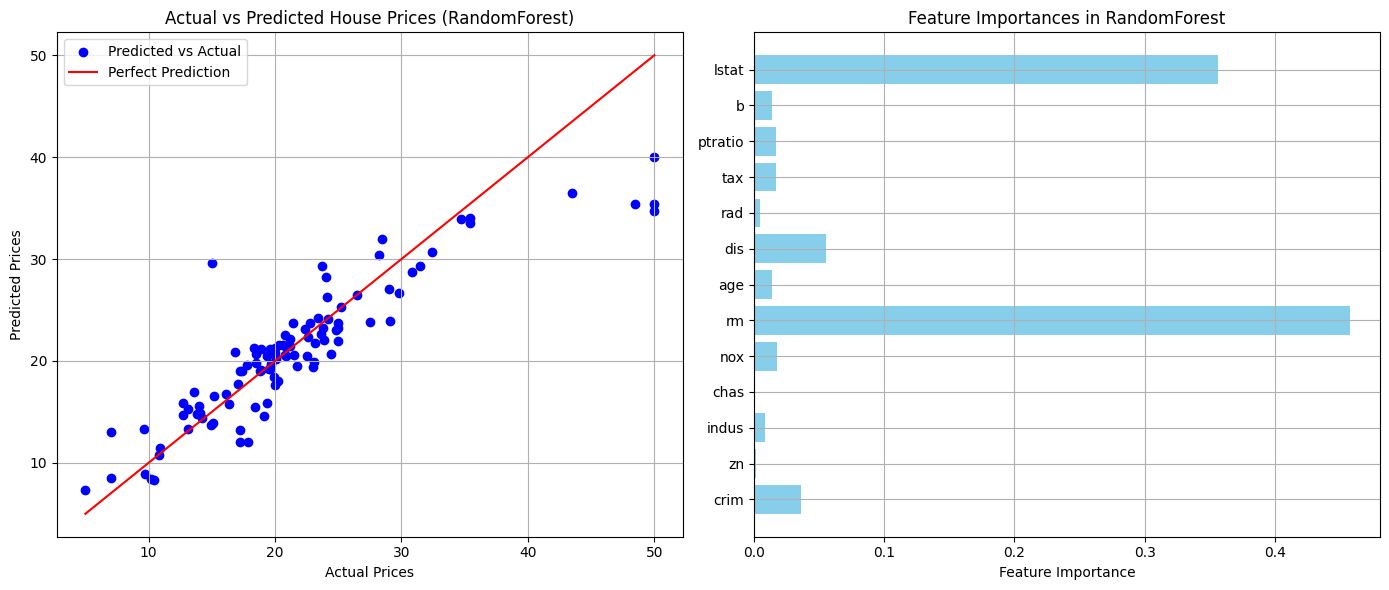

In [99]:
# # Step 4,5,6: Model Fitting, Test, Evaluation 
# # Model Fitting (RandomForestRegressor(random_state=100))

# model = RandomForestRegressor(random_state=100)
# model.fit(x_train, y_train)
# y_predict = model.predict(x_test)

# print("MSE: {}".format(mean_squared_error(y_test, y_predict)))
# print("MAE: {}".format(mean_absolute_error(y_test, y_predict)))
# print("R2: {}".format(r2_score(y_test, y_predict)))

# # Step 7: Model Coefficients and Intercept (NOT applicable to RandomForest)
# # We skip coef_ and intercept for RandomForestRegressor, as they do not exist

# # Step 8: Feature Importance (Random Forest)
# # Note: Non-linear model, we use importances = model.feature_importances_  to Get feature importances
# importances = model.feature_importances_  
# features = x_train.columns  

# # Print feature importance in descending order
# feature_importance = sorted(zip(features, importances), key=lambda x: abs(x[1]), reverse=True)
# for feature, importance in feature_importance:
#     print(f"Feature: {feature}\nImportance: {importance:.2f}\n")
  
# # Step 9: Plotting
# fig, ax = plt.subplots(1, 2, figsize=(14, 6))  # 1 row, 2 columns

# # 1: Plotting Actual vs Predicted values
# ax[0].scatter(y_test, y_predict, color='blue', label='Predicted vs Actual')
# ax[0].plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', label='Perfect Prediction')
# ax[0].set_title('Actual vs Predicted House Prices (RandomForest)')
# ax[0].set_xlabel('Actual Prices')
# ax[0].set_ylabel('Predicted Prices')
# ax[0].legend()
# ax[0].grid(True)

# # 2: Bar chart for Feature Importances
# ax[1].barh(features, importances, color='skyblue')
# ax[1].set_xlabel('Feature Importance')
# ax[1].set_title('Feature Importances in RandomForest')
# ax[1].grid(True)

# plt.tight_layout()
# plt.show()
    
# # Out 
# # MSE: 14.676357764705877
# # MAE: 2.459882352941176
# # R2: 0.7998690762670693

# # Feature: rm
# # Importance: 0.46

# # Feature: lstat
# # Importance: 0.36